In [ ]:
# Standard library imports (e.g., OS, datetime, etc.)
import os
import typing
import datetime
from pathlib import Path
import shutil

# Third-party libraries
import numpy as np
import polars as pl
import seaborn as sns
import pandas as pd
# from polars.testing.parametric import columns
from tqdm import tqdm
import geopy.distance
import scipy
import sklearn
import geopandas
import shapely
# import shapely.geometry
import matplotlib.pyplot as plt
# import matplotlib.animation as animation

import torch
import torch_geometric_temporal

import contextily as ctx
from h3 import h3


In [15]:
start_date = datetime.datetime(2010, 1, 1, 0, 0)
end_date = datetime.datetime(2020, 12, 31, 0, 0)

seed = 3435
torch.manual_seed(seed)
split_index = 730

pl.enable_string_cache()

data_path = r'kansas_asos_2010_2020.csv'

NameError: name 'datetime' is not defined

In [3]:
metar_schema = {'station': pl.Categorical,
                'valid': pl.Datetime,
                'lon': pl.Float64,
                'lat': pl.Float64,
                'elevation': pl.Float64,
                'tmpf': pl.Float64,
                'dwpf': pl.Float64,
                'relh': pl.Float64,
                'drct': pl.Float64,
                'sknt': pl.Float64,
                'p01i': pl.Float64,
                'alti': pl.Float64,
                'mslp': pl.Float64,
                'vsby': pl.Float64,
                'gust': pl.Float64,
                'skyc1': pl.Categorical,
                'skyc2': pl.Categorical,
                'skyc3': pl.Categorical,
                'skyc4': pl.Categorical,
                'skyl1': pl.Float64,
                'skyl2': pl.Float64,
                'skyl3': pl.Float64,
                'skyl4': pl.Float64,
                'wxcodes': pl.String,
                'ice_accretion_1hr': pl.Float64,
                'ice_accretion_3hr': pl.Float64,
                'ice_accretion_6hr': pl.Float64,
                'peak_wind_gust': pl.Float64,
                'peak_wind_drct': pl.Float64,
                'peak_wind_time': pl.Datetime,
                'feel': pl.Float64,
                'metar': pl.String,
                'snowdepth': pl.Float64}

In [4]:
asos_ldf = pl.scan_csv(data_path, null_values=['T', 'M', '///'], schema=metar_schema)\
    .drop('metar')\
    .with_columns(pl.col('valid').dt.round('1h').alias('valid'))

In [5]:
full_date_series = np.arange(start_date, end_date, datetime.timedelta(hours=1))

asos_df = asos_ldf\
    .collect()\
    .select(pl.col('station', 'lat', 'lon', 'elevation'))\
    .unique()\
    .join(pl.DataFrame({'valid': full_date_series}), how='cross')\
    .join(asos_ldf.collect(), on=['station', 'valid'], how='left')\
    .with_columns(pl.col('valid').dt.round('6h').alias('valid'))\
    .drop('lat_right', 'lon_right', 'elevation_right')\
    .group_by(['station', 'valid'])\
    .mean()\
    .with_columns(pl.col(pl.Float64).cast(pl.Float32))

In [296]:
full_date_series.shape

(96408,)

In [6]:
potential_features = asos_ldf.drop('valid', 'station', 'lat', 'lon', 'elevation').collect_schema().names()
feature_list = []

for feature in potential_features:
    if not asos_df.select(pl.col(feature).is_null().all()).item():
        feature_list.append(feature)

stations_list = asos_df\
    .select(pl.col('station'))\
    .unique()\
    .to_series()\
    .to_list()

In [7]:
def safe_index(item, lst):
    return item in lst

In [8]:
year_series = np.arange(start_date.year, end_date.year + 1, 1)
reduced_feature_df = pl.DataFrame(schema={**{'start_year': pl.Int64, 'end_year': pl.Int64, 'year_range': pl.Int64, 'year_label': pl.String, 'feature': pl.String},
                                          **{station: pl.Boolean for station in stations_list}
                                          })

for index, a in enumerate(tqdm(year_series)):
    for b in year_series[index:]:
        shifted_date_series = np.arange(datetime.date(a, 1, 1), datetime.date(b, 12, 31), datetime.timedelta(hours=6))
        year_filter_df = asos_df.filter(pl.col('valid').dt.year().is_between(a, b))
        for feature in feature_list:
            if (year_filter_df.select(pl.col(feature).null_count()) != year_filter_df.height).item():
                asos_pivot_df = year_filter_df\
                    .pivot(on='station', index='valid', values=feature, aggregate_function='mean')\
                    .drop('valid')
                valid_stations = [s.name for s in asos_pivot_df if not (s.null_count() > len(shifted_date_series)*0.1)]
                if len(valid_stations) >= 6:
                    if asos_pivot_df.var().select(pl.mean_horizontal(pl.all()).alias('mean')).item() > 5:
                        valid_stations.sort()
                        new_row = pl.DataFrame({**{'start_year': a,
                                                   'end_year': b,
                                                   'year_range': (b+1) - a,
                                                   'year_label': f'{a}-{b}',
                                                   'feature': feature},
                                                **{station: safe_index(station, valid_stations) for station in stations_list}
                                                })
                        reduced_feature_df = reduced_feature_df.vstack(new_row)

100%|██████████| 11/11 [00:13<00:00,  1.22s/it]


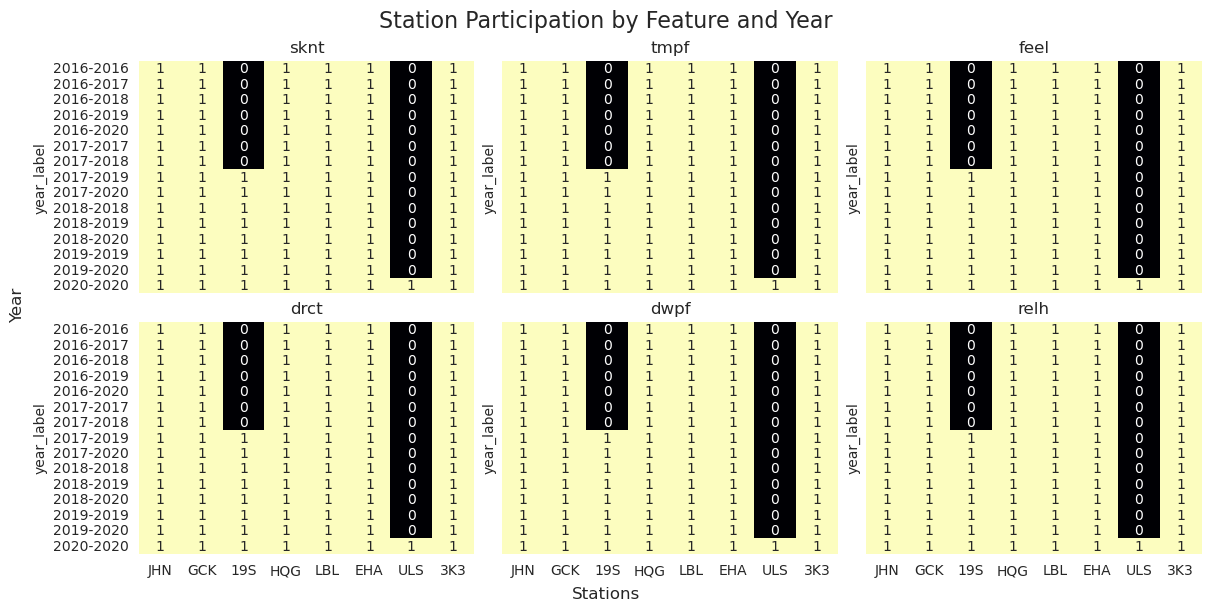

In [297]:
features = reduced_feature_df.select(pl.col('feature')).unique().to_series().to_list()

n_cols = 3
n_rows = -(-len(features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), constrained_layout=True,
                         sharex=True, sharey=True)
axes = axes.flatten()

for idx, feature in enumerate(features):
    plot_df = (
        reduced_feature_df
        .filter(pl.col('feature') == feature)
        .drop('feature', 'start_year', 'end_year', 'year_range')
        .to_pandas()
    )

    plot_df.index = plot_df['year_label'].astype(str)
    plot_df = plot_df.drop('year_label', axis=1)
    plot_df = plot_df.sort_index()

    ax = axes[idx]
    sns.heatmap(plot_df, cmap='magma', annot=True, cbar=False, ax=ax)

    ax.set_title(feature)

# Shared axis labels
fig.suptitle("Station Participation by Feature and Year", fontsize=16)
fig.supxlabel("Stations")
fig.supylabel("Year")

plt.show()


In [10]:
df_t = reduced_feature_df\
    .filter(pl.col('year_label').eq('2018-2020'))\
    .drop('year_range', 'year_label', 'start_year', 'end_year')\
    .transpose(include_header=True)


new_headers = df_t.row(0)

df_t_no_header = df_t.slice(1, df_t.height - 1)

df_t_renamed = df_t_no_header.rename({old: str(new) for old, new in zip(df_t_no_header.columns, new_headers)})

In [11]:
valid_features = [col for col in df_t_renamed.columns if col != "feature"]
valid_stations = df_t_renamed\
    .with_columns(pl.col(valid_features)\
                  .map_elements(lambda x: x == 'true', return_dtype=pl.Boolean))\
    .filter( pl.all_horizontal([pl.col(col) for col in valid_features]))\
    .select(pl.col('feature'))\
    .to_series()\
    .to_list()

In [12]:
reduced_asos_df = asos_df\
    .filter(pl.col('valid').is_between(datetime.datetime(2018, 1, 1, 0, 0), datetime.datetime(2021, 1, 1, 0, 0)))\
    .filter(pl.col('station').is_in(valid_stations))\
    .select(pl.col(['station', 'valid', 'lat', 'lon', 'elevation'] + valid_features))\
    .sort(['valid', 'station'])\
    .with_columns([(pl.col('drct').map_elements(lambda x: np.sin(np.radians(x)), return_dtype=pl.Float64)).alias('drct_sin'),
                   (pl.col('drct').map_elements(lambda x: np.cos(np.radians(x)), return_dtype=pl.Float64)).alias('drct_cos')])\
    .drop('drct')

row_count, feature_count = reduced_asos_df.drop('station', 'valid', 'lat', 'lon', 'elevation').shape
valid_station = reduced_asos_df.select(pl.col('station')).head(7).to_series().to_list()
station_count = len(valid_station)
valid_features = reduced_asos_df.drop('station', 'valid', 'lat', 'lon', 'elevation').columns

station_matrix = reduced_asos_df.drop('station', 'valid', 'lat', 'lon', 'elevation').to_numpy().reshape(int(row_count/station_count), station_count, feature_count)

In [13]:
not np.any(np.all(np.isnan(station_matrix), axis=(1, 2)))

True

In [14]:
# calculate the geodesic distance between two nodes
def compute_node_distance(node1, node2, inverse=False):
    coords_1 = (node1[1], node1[0])
    coords_2 = (node2[1], node2[0])
    horizontal_distance = geopy.distance.geodesic(coords_1, coords_2).km
    if inverse:
        try:
            horizontal_distance = 1/horizontal_distance
        except ZeroDivisionError:
            horizontal_distance = 0
    return horizontal_distance

In [15]:
reduced_asos_df

station,valid,lat,lon,elevation,tmpf,dwpf,relh,sknt,feel,drct_sin,drct_cos
cat,datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f64,f64
"""GCK""",2018-01-01 00:00:00,37.927502,-100.724403,881.0,9.283334,-6.5,48.148335,8.666667,-4.161667,0.851117,0.524977
"""LBL""",2018-01-01 00:00:00,37.044201,-100.9599,879.0,12.316667,-1.983333,52.014999,10.166667,-1.721667,0.664796,0.747025
"""EHA""",2018-01-01 00:00:00,37.000801,-101.879997,1099.0,15.555555,5.255556,63.382778,7.388889,4.482222,0.970763,0.24004
"""HQG""",2018-01-01 00:00:00,37.163101,-101.370499,956.52002,14.311111,-1.605556,48.468334,7.777778,2.681667,0.936332,0.351115
"""3K3""",2018-01-01 00:00:00,37.991699,-101.7463,1005.700012,13.1,-0.9,53.127777,6.777778,2.151111,0.981255,0.192712
…,…,…,…,…,…,…,…,…,…,…,…
"""EHA""",2020-12-31 00:00:00,37.000801,-101.879997,1099.0,42.355556,16.588888,34.955555,3.0,40.254444,-0.533205,-0.845986
"""HQG""",2020-12-31 00:00:00,37.163101,-101.370499,956.52002,40.722221,13.255555,32.23111,1.666667,39.450001,0.977334,-0.211704
"""3K3""",2020-12-31 00:00:00,37.991699,-101.7463,1005.700012,40.200001,12.2,31.377777,4.555555,36.683334,-0.700217,-0.71393


In [16]:
station_df = reduced_asos_df.select(pl.col(['station', 'lon', 'lat', 'elevation'])).unique().to_pandas()
grid_list = station_df.loc[:, ['lon', 'lat']].reset_index()[['lon', 'lat', 'index']].to_numpy().tolist()
grid_list = [sublist[:-1] + [int(sublist[-1])] for sublist in grid_list]


result_dict = {'index': [],
               'station': []}
result_dict = {**result_dict, **{str(i): [] for _, _, i in grid_list}}

for row_index, station in station_df.iterrows():
    for col_index, station2 in station_df.iterrows():
        result_dict[str(col_index)].append(compute_node_distance([station['lon'], station['lat']], [station2['lon'], station2['lat']], inverse=True))
    result_dict['station'].append(station['station'])
    result_dict['index'].append(row_index)

grid_map_df = pl.DataFrame(result_dict, schema={**{'station': pl.Categorical, 'index': pl.UInt64}, **{str(i): pl.Float64 for _, _, i in grid_list}})

In [17]:
scaled_idistance = sklearn.preprocessing.minmax_scale(grid_map_df.drop('station', 'index'))
modified_adjacency_df = grid_map_df.select(pl.col(['station', 'index']))\
    .join(pl.DataFrame(scaled_idistance, schema=[str(i) for i, _ in enumerate(scaled_idistance)]).with_row_index(),
          on='index')

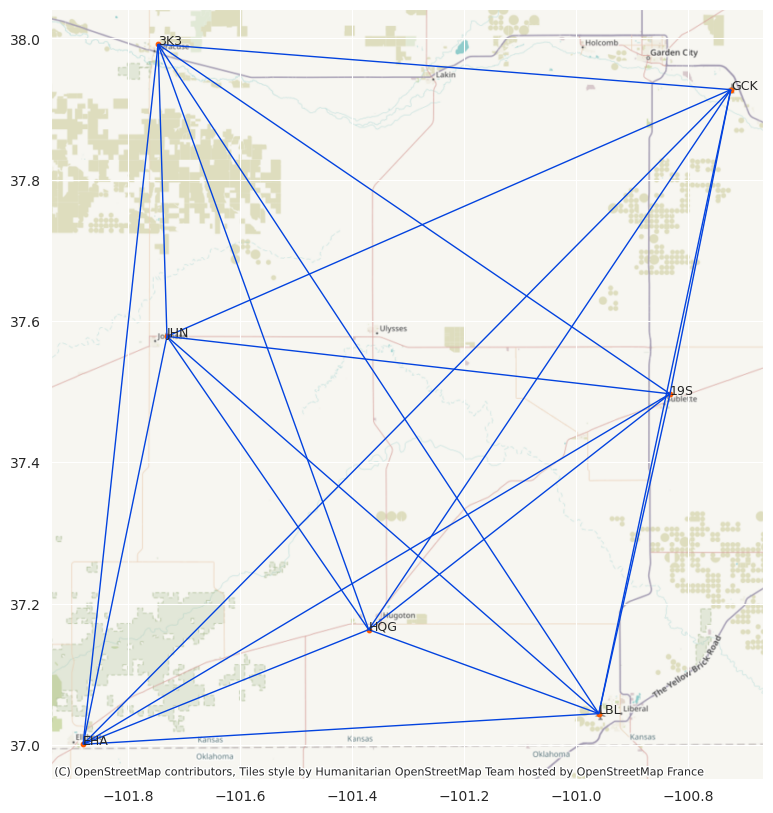

In [18]:
station_node_list = [shapely.geometry.Point(lon, lat) for lat, lon in station_df[['lat', 'lon']].to_numpy()]
stations_gdf = geopandas.GeoDataFrame(station_df.copy(), geometry=station_node_list, crs="EPSG:4326")

edge_list = []
n = len(station_node_list)
for i in range(n):
    for j in range(i + 1, n):
        edge_list.append(shapely.geometry.LineString([station_node_list[i], station_node_list[j]]))

edges_gdf = geopandas.GeoDataFrame(geometry=edge_list, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(18, 10))

edges_gdf.plot(ax=ax, color="xkcd:blue", linewidth=1, alpha=1)

stations_gdf.plot(ax=ax, color="xkcd:bright orange", markersize=10)

for i, row in stations_gdf.iterrows():
    ax.text(row.geometry.x, row.geometry.y, row['station'], fontsize=9)

ctx.add_basemap(ax, crs=stations_gdf.crs.to_string())

In [19]:
adj = modified_adjacency_df.drop('station', 'index').to_numpy()
adj = adj / adj.sum(axis=1, keepdims=True)

def spatial_impute(data, adj):
    imputed = data.copy()
    T, N, F = data.shape

    for t in range(T):
        for i in range(N):
            for f in range(F):
                if np.isnan(imputed[t, i, f]):
                    neighbor_vals = imputed[t, :, f]
                    weights = adj[i]
                    mask = ~np.isnan(neighbor_vals)

                    if mask.sum() > 0:
                        imputed[t, i, f] = np.dot(weights[mask], neighbor_vals[mask]) / weights[mask].sum()

    return imputed

def spatiotemporal_impute(data, adj):
    data = spatial_impute(data, adj)

    T, N, F = data.shape
    for i in tqdm(range(N)):
        for f in range(F):
            series = data[:, i, f]
            mask = ~np.isnan(series)
            if mask.sum() == 0:
                continue
            indices = np.arange(T)
            data[:, i, f] = np.interp(indices, indices[mask], series[mask])

    return data

data_imputed = spatiotemporal_impute(station_matrix, adj)

100%|██████████| 7/7 [00:00<00:00, 4073.83it/s]


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

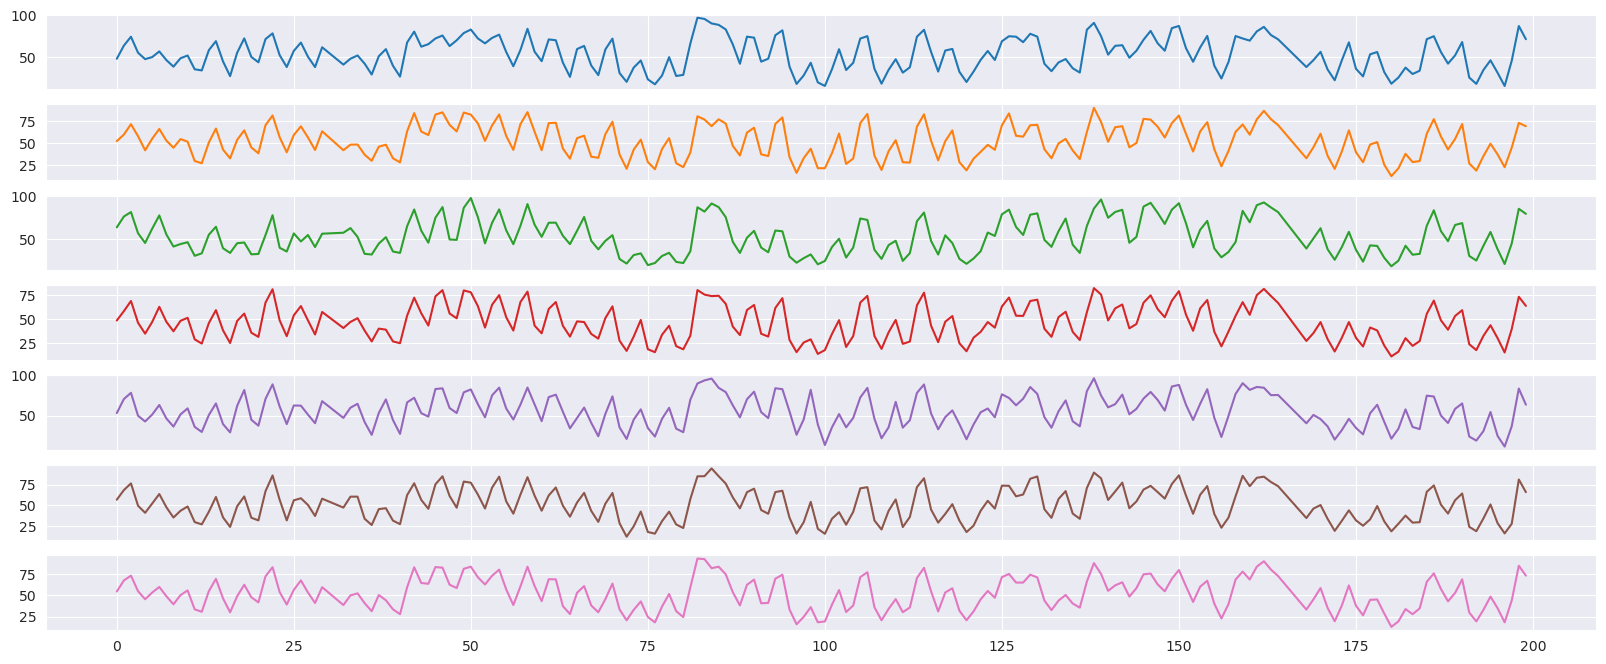

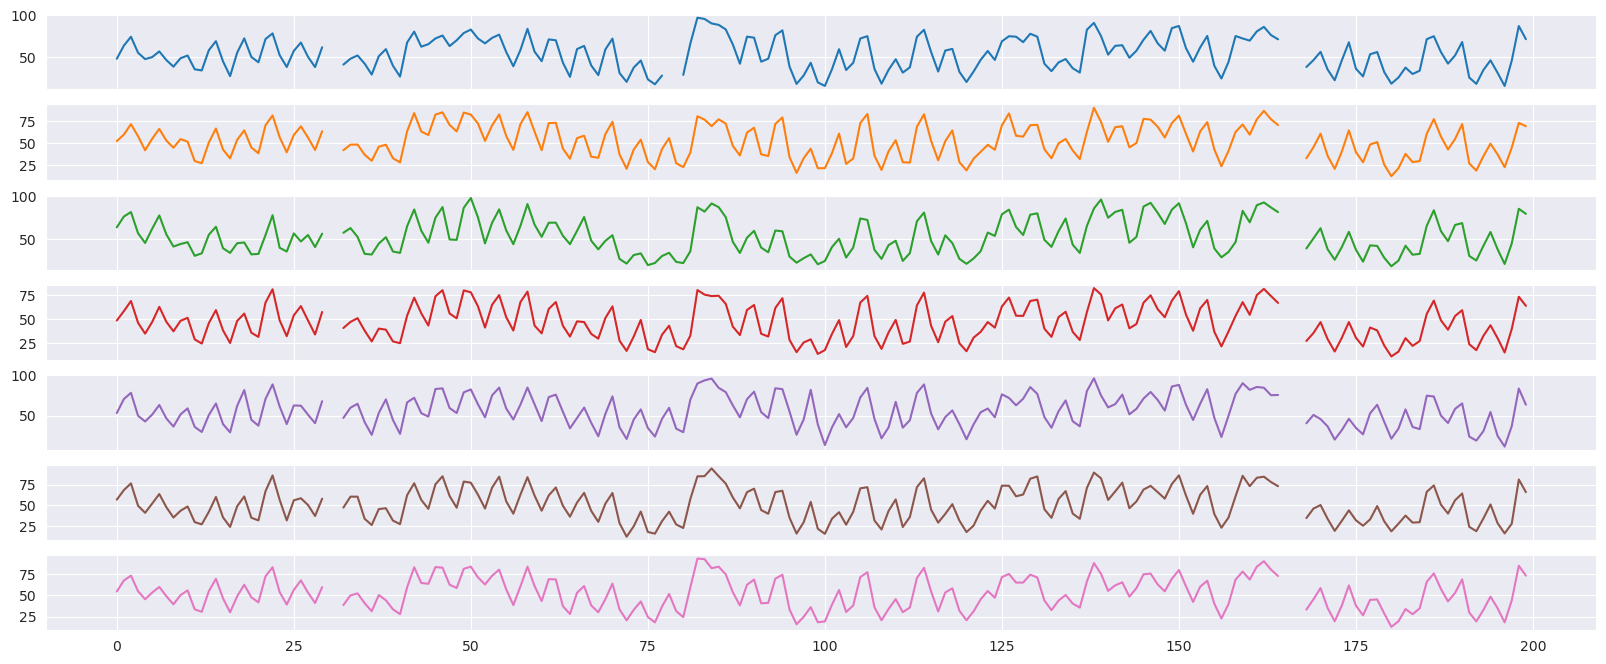

In [20]:
pd.DataFrame(data_imputed[:200, :, 2]).plot(legend=False, subplots=True, figsize=(20, 8))
pd.DataFrame(station_matrix[:200, :, 2]).plot(legend=False, subplots=True, figsize=(20, 8))

In [21]:
def node_correlation(data, node_number):
    T, N, F = data.shape

    corr_within_node = np.empty((N, F, F))

    for node in range(N):
        node_data = data[:, node, :]
        corr_within_node[node] = np.corrcoef(node_data, rowvar=False)

    corr_list = []
    for f_feature in range(F):
        inner_list = []
        for s_feature in range(F):
            if f_feature < s_feature:
                inner_list.append(np.nan)
            else:
                inner_list.append(float(corr_within_node[node_number, f_feature, s_feature]))
        corr_list.append(inner_list)
    return corr_list

In [22]:
def between_node_correlation(data, feature_number):

    feature_data = data[:, :, feature_number]

    corr_between_nodes = np.corrcoef(feature_data.T)
    corr_between_nodes[np.triu_indices(corr_between_nodes.shape[0], 1)] = np.nan

    return corr_between_nodes

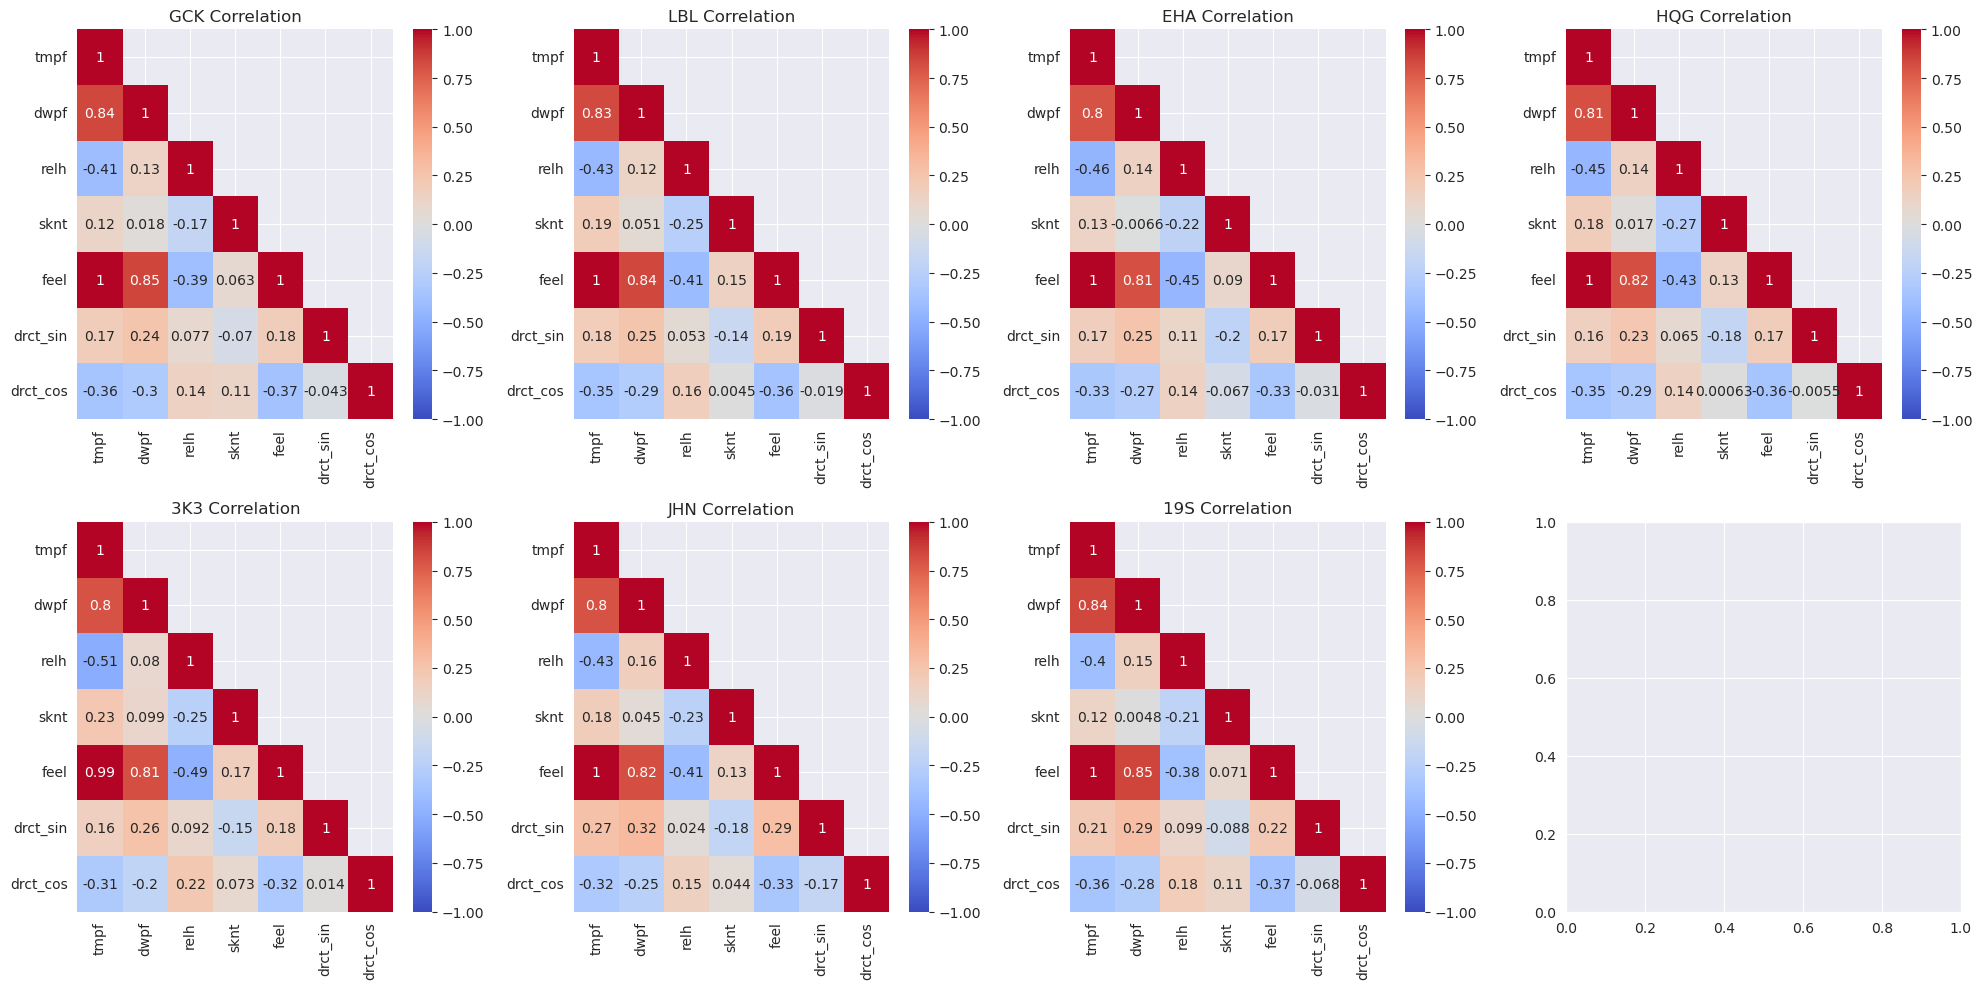

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(data_imputed.shape[1]):
    corr_matrix = pd.DataFrame(
        node_correlation(data_imputed, i),
        columns=valid_features,
        index=valid_features
    )
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i])
    axes[i].set_title(f'{valid_station[i]} Correlation')

plt.tight_layout()
plt.show()

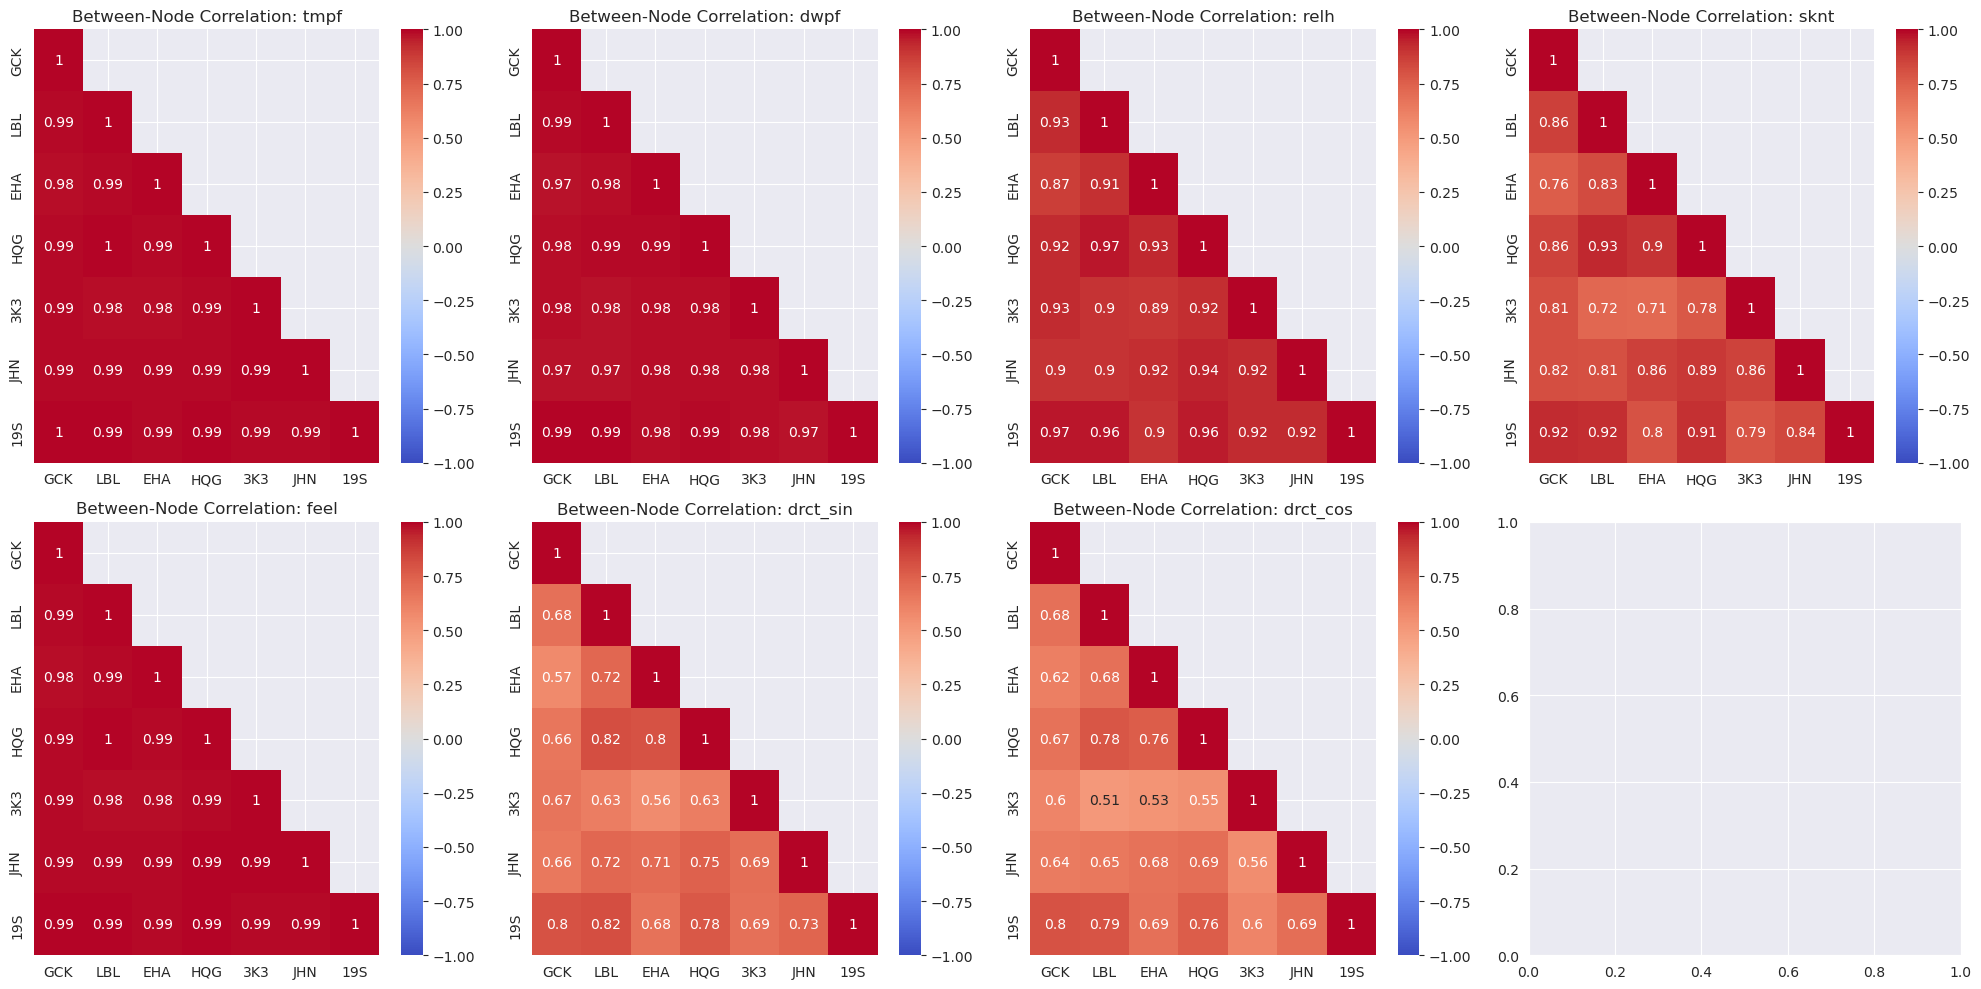

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(data_imputed.shape[2]):
    corr_matrix = pd.DataFrame(
        between_node_correlation(data_imputed, i),
        columns=valid_station,
        index=valid_station
    )
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i])
    axes[i].set_title(f'Between-Node Correlation: {valid_features[i]}')

plt.tight_layout()
plt.show()

In [229]:
T, N, F = data_imputed.shape
imputed_df = pl.from_numpy(data_imputed.reshape(T * N, F), schema=valid_features)\
    .drop('dwpf', 'feel')\
    .with_columns(pl.DataFrame([valid_station[i % len(valid_station)] for i in range(T*N)], schema={'station': pl.Categorical})\
          .join(pl.from_pandas(station_df),
                on='station',
                how='left'))\
    .select(pl.col(['station', 'lon', 'lat', 'elevation', 'tmpf', 'relh', 'sknt', 'drct_sin', 'drct_cos']))\
    .drop('lon', 'lat', 'elevation')\
    .with_columns(pl.col('relh')/100)

imputed_df = imputed_df.drop('tmpf', 'sknt')\
    .hstack(pl.DataFrame(sklearn.preprocessing.robust_scale(imputed_df.select(pl.col('tmpf'))), schema=['tmpf']))\
    .hstack(pl.DataFrame(sklearn.preprocessing.robust_scale(imputed_df.select(pl.col('sknt'))), schema=['sknt']))\
    .select(pl.col(['station', 'tmpf', 'relh', 'sknt', 'drct_sin', 'drct_cos']))

imputed_df

station,tmpf,relh,sknt,drct_sin,drct_cos
cat,f64,f64,f64,f64,f64
"""GCK""",-1.355721,0.481483,-0.080357,0.851117,0.524977
"""LBL""",-1.265174,0.52015,0.160714,0.664796,0.747025
"""EHA""",-1.168491,0.633828,-0.285714,0.970763,0.24004
"""HQG""",-1.205638,0.484683,-0.223214,0.936332,0.351115
"""3K3""",-1.241791,0.531278,-0.383929,0.981255,0.192712
…,…,…,…,…,…
"""EHA""",-0.368491,0.349556,-0.991072,-0.533205,-0.845986
"""HQG""",-0.417247,0.322311,-1.205357,0.977334,-0.211704
"""3K3""",-0.432836,0.313778,-0.741072,-0.700217,-0.71393


In [230]:
# if the station is going to be used for linear regression apply a one-hot encoding to it
imputed_pd_df = imputed_df.to_pandas()
imputed_pl_df = imputed_df.drop('station')

In [231]:
row_count, feature_count = imputed_pl_df.shape
station_count = imputed_df.select(pl.col('station').unique()).count().item()
np_imp_array = imputed_pl_df.to_numpy().reshape(int(row_count/station_count), station_count, feature_count)

In [232]:
def concat_past_timesteps(data, window=4):
    T, _, _ = data.shape

    slices = [data[i:T - window + i + 1] for i in range(window)]

    return np.concatenate(slices[::-1], axis=2)

lagged_array = concat_past_timesteps(np_imp_array, 28)

In [233]:
# implement lightning
# change target from temp to all features

T, N, F = lagged_array.shape

edge_index = [[i, j] for i in range(N) for j in range(N) if i != j]
edge_weight = np.array([float(adj[edge[0], edge[1]]) for edge in edge_index])
edge_index = np.array(edge_index).T
features = [lagged_array[t, :, :] for t in range(T-1)]
targets = [lagged_array[t+1, :, 0] for t in range(T-1)]

In [234]:
class RecurrentGCN(torch.nn.Module):
    def __init__(self, node_features):
        super(RecurrentGCN, self).__init__()
        self.recurrent1 = torch_geometric_temporal.nn.recurrent.DCRNN(node_features, 64, 1)
        self.recurrent2 = torch_geometric_temporal.nn.recurrent.DCRNN(64, 32, 1)
        self.recurrent3 = torch_geometric_temporal.nn.recurrent.DCRNN(32, 32, 1)

        self.linear = torch.nn.Linear(32, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.recurrent1(x, edge_index, edge_weight)
        h = torch.nn.functional.relu(h)

        h = self.recurrent2(h, edge_index, edge_weight)
        h = torch.nn.functional.relu(h)

        h = self.recurrent3(h, edge_index, edge_weight)
        h = torch.nn.functional.relu(h)

        h = self.linear(h)
        return h

In [235]:
dataset = torch_geometric_temporal.signal.StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=features,
    targets=targets
)

train_dataset, test_dataset = torch_geometric_temporal.temporal_signal_split(dataset, train_ratio=(T-split_index)/T)
train_dataset, validation_dataset = torch_geometric_temporal.temporal_signal_split(train_dataset, train_ratio=0.8)

gnn_model = RecurrentGCN(node_features = F)

optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    min_lr=1e-5,
)

In [236]:
if not os.path.exists('best_model.pt'):
    best_loss = float('inf')
    patience = 10
    trigger_times = 0
    target_epochs = 100

    gnn_model.train()
    with tqdm(total=target_epochs) as pbar:
        for epoch in range(target_epochs):
            gnn_model.train()
            torch.enable_grad()
            train_cost = 0

            for time, snapshot in enumerate(train_dataset):
                y_hat = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
                train_cost += torch.mean((y_hat - snapshot.y)**2)

            train_cost /= (time + 1)
            train_cost.backward()
            optimizer.step()
            optimizer.zero_grad()

            scheduler.step(train_cost.item())

            gnn_model.eval()
            val_loss = 0
            with torch.no_grad():
                for time, snapshot in enumerate(validation_dataset):
                    y_hat = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
                    val_loss += torch.mean((y_hat - snapshot.y)**2)
                val_loss /= (time + 1)

            pbar.set_postfix({
                'train_loss': train_cost.item(),
                'val_loss': val_loss.item(),
                'lr': optimizer.param_groups[0]['lr']
            })
            pbar.update(1)

            if best_loss < 0.05 and epoch > 1:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

            if val_loss.item() < best_loss:
                best_loss = val_loss.item()
                trigger_times = 0
                torch.save(gnn_model.state_dict(), 'best_model.pt')
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"Early stopping triggered at epoch {epoch + 1}")
                    break
else:
    gnn_model.load_state_dict(torch.load('best_model.pt'))

In [237]:
gnn_model.eval()
cost = 0
for time, snapshot in enumerate(test_dataset):
    y_hat = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
    cost = cost + torch.mean((y_hat - snapshot.y)**2)
cost = cost / (time+1)
cost = cost.item()
print("MSE: {:.4f}".format(cost))

MSE: 0.0562


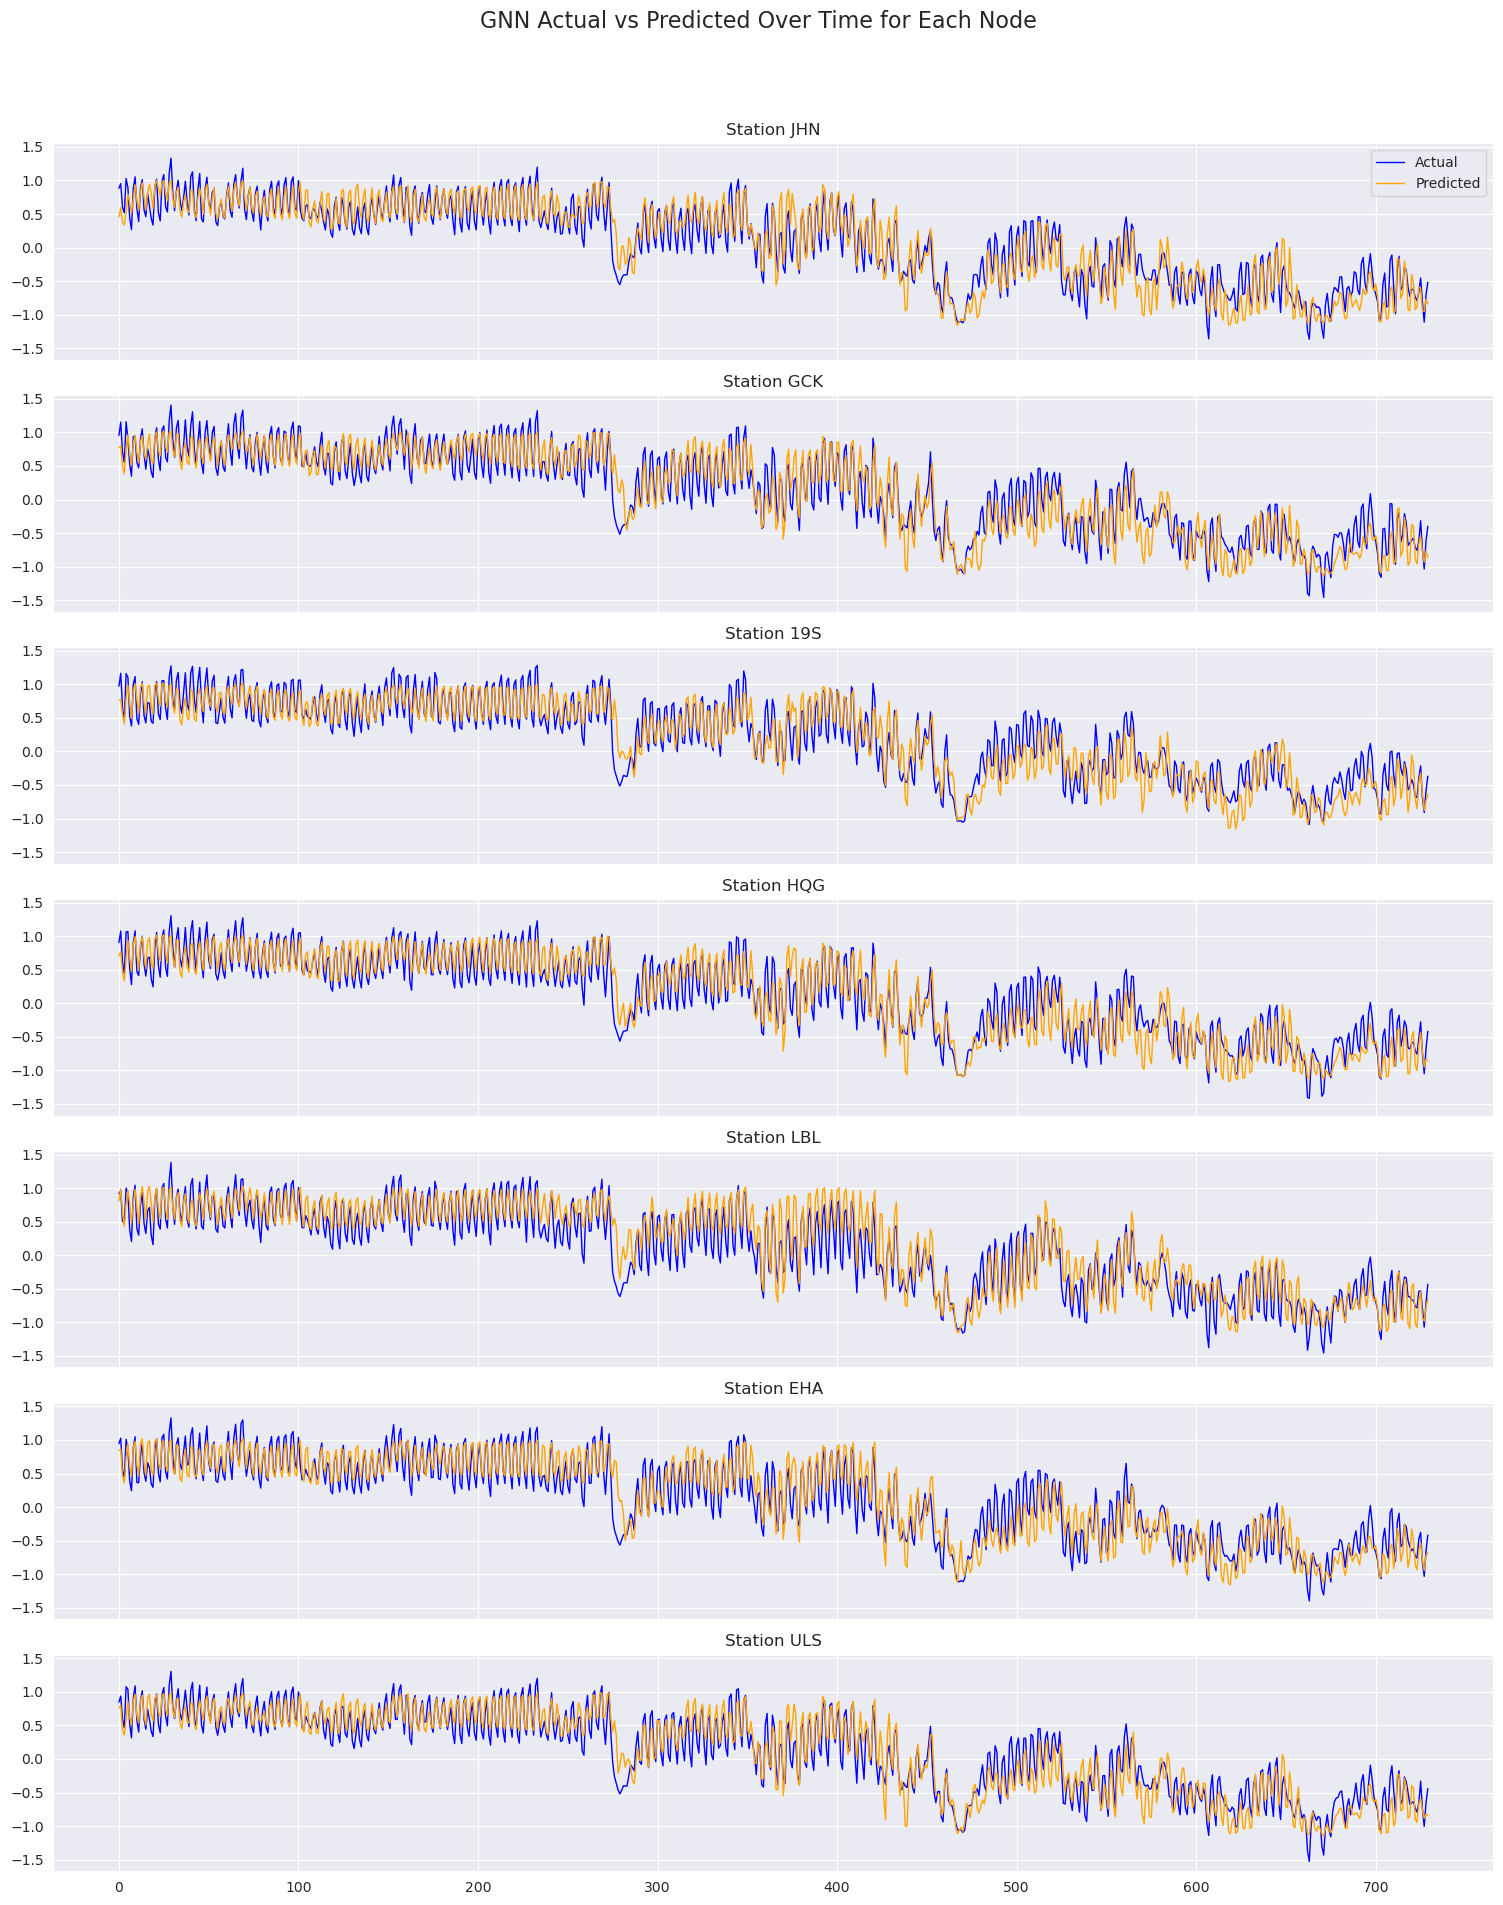

In [288]:
all_preds = []
all_targets = []

gnn_model.eval()
with torch.no_grad():
    for snapshot in test_dataset:
        y_pred = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze()
        y_true = snapshot.y.squeeze()
        all_preds.append(y_pred.cpu().numpy())
        all_targets.append(y_true.cpu().numpy())

# Convert to arrays: shape [num_snapshots, num_nodes]
all_preds = np.stack(all_preds)
all_targets = np.stack(all_targets)

num_nodes = all_preds.shape[1]
num_time_steps = all_preds.shape[0]

cols = 1  # number of columns of facets
rows = num_nodes

fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=True, sharey=True)

for node in range(num_nodes):
    ax = axes[node]
    ax.plot(all_targets[:, node], label='Actual', color='blue', linewidth=1)
    ax.plot(all_preds[:, node], label='Predicted', color='orange', linewidth=1)
    ax.set_title(f'Station {stations_list[node]}')
    ax.grid(True)

# Only add legend to one plot
axes[0].legend(loc='upper right')

fig.suptitle("GNN Actual vs Predicted Over Time for Each Node", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

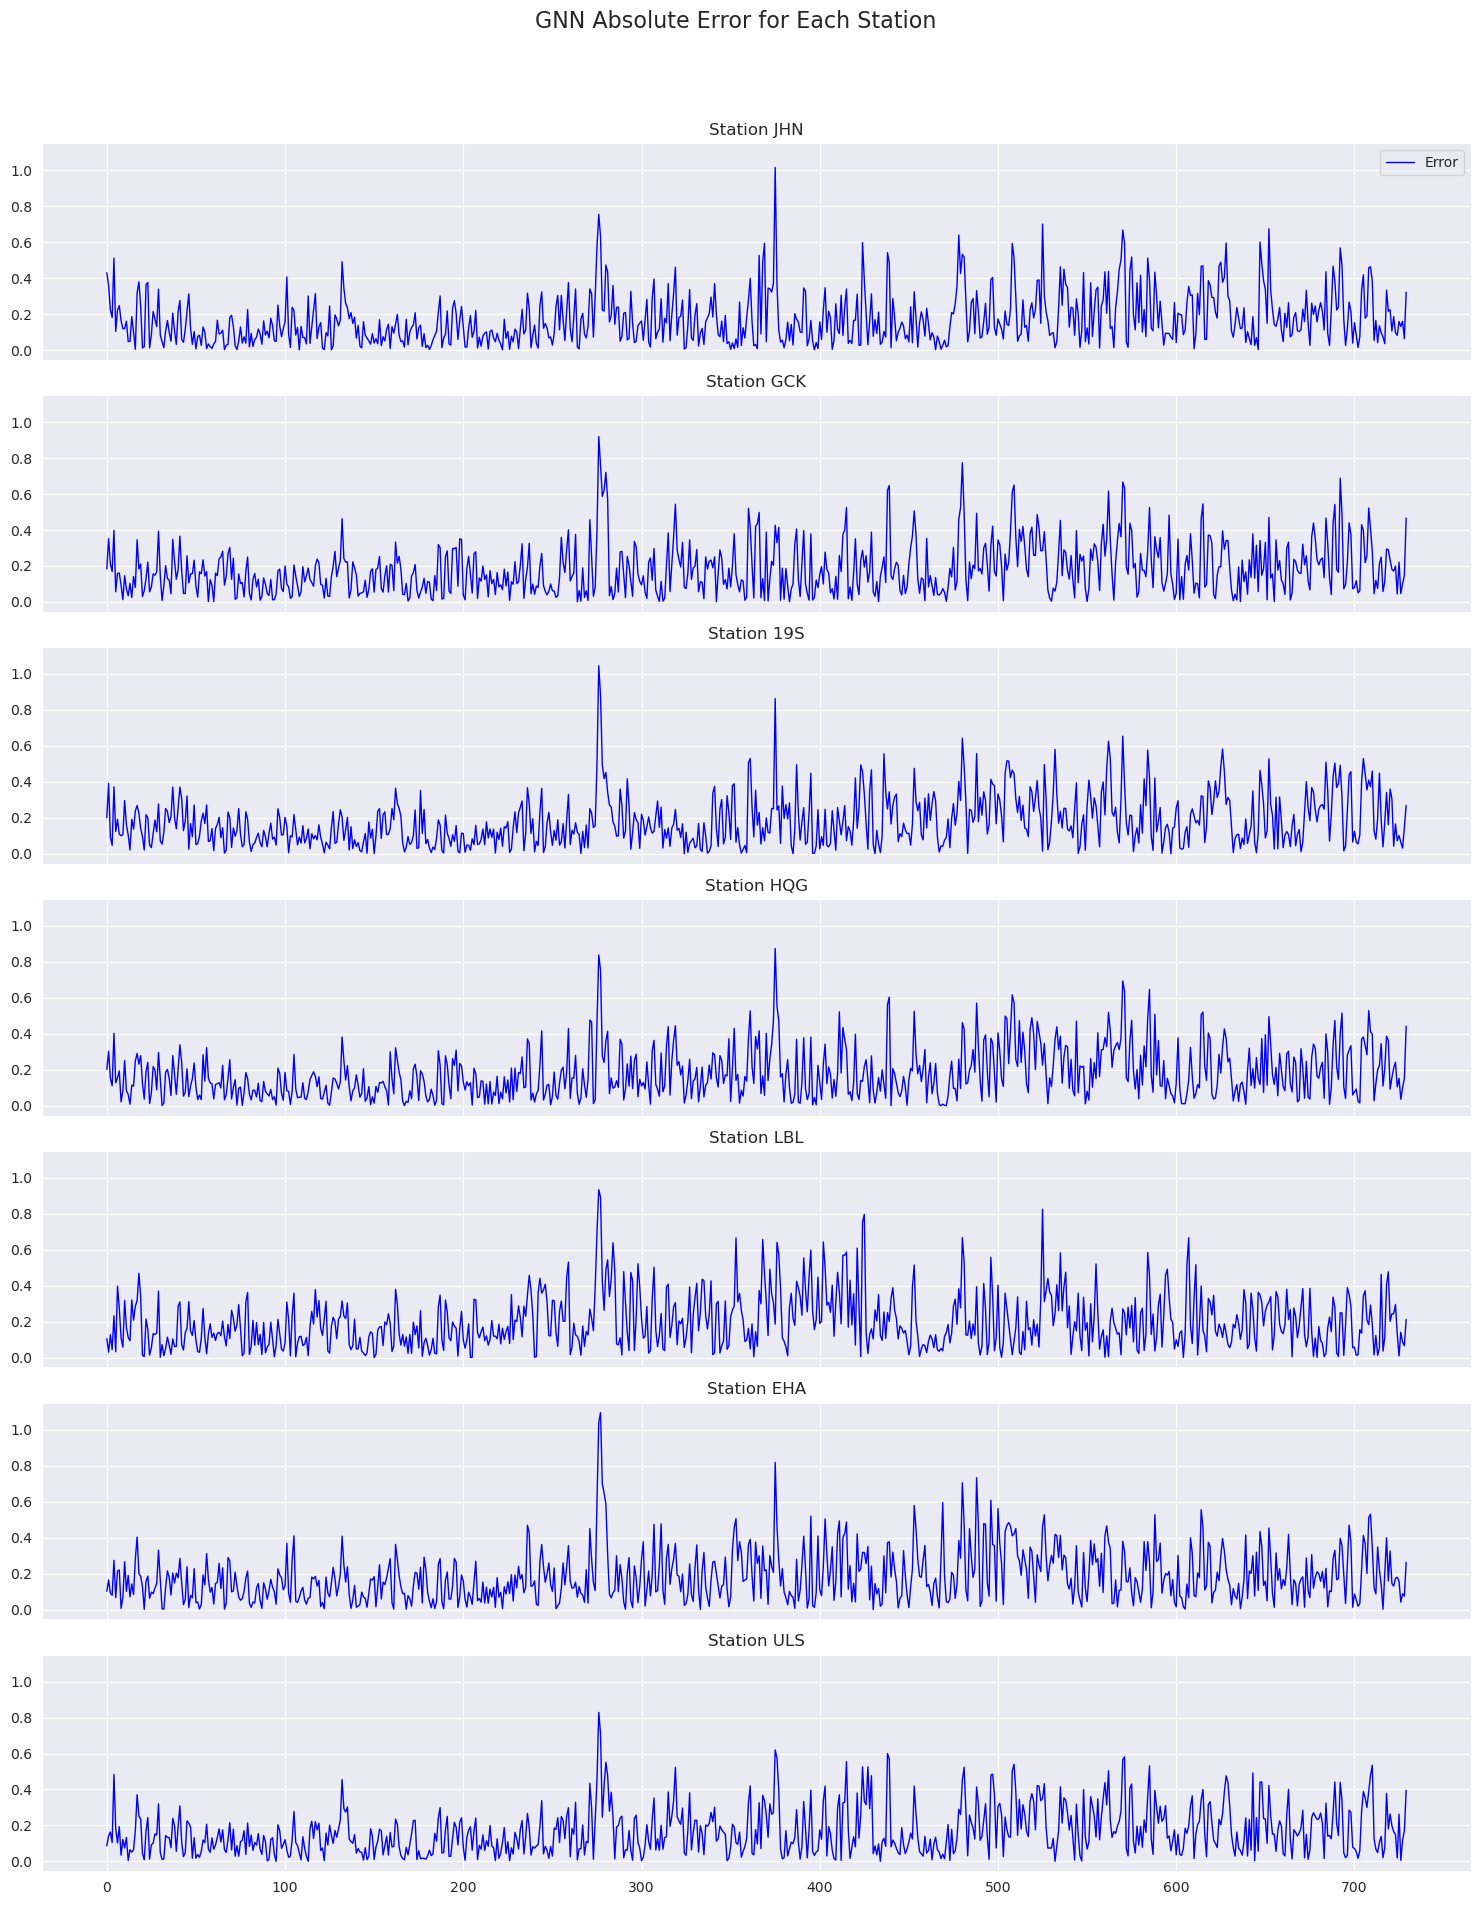

In [266]:
all_preds = []
all_targets = []

gnn_model.eval()
with torch.no_grad():
    for snapshot in test_dataset:
        y_pred = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze()
        y_true = snapshot.y.squeeze()
        all_preds.append(y_pred.cpu().numpy())
        all_targets.append(y_true.cpu().numpy())

# Convert to arrays: shape [num_snapshots, num_nodes]
all_preds = np.stack(all_preds)
all_targets = np.stack(all_targets)

gnn_absolute_error = np.abs(np.subtract(np.array(all_preds, dtype=float), np.array(all_targets, dtype=float)))

fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=True, sharey=True)
for node in range(num_nodes):
    ax = axes[node]
    ax.plot(gnn_absolute_error[:, node], label='Error', color='blue', linewidth=1)
    ax.set_title(f'Station {stations_list[node]}')
    ax.grid(True)

axes[0].legend(loc='upper right')

fig.suptitle("GNN Absolute Error for Each Station", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [261]:
flattened_array = np.mean(lagged_array, axis=1)

T, N, F = lagged_array.shape

X = flattened_array[:-1]
X_train, X_test = np.split(X, [T-split_index])
y_true = flattened_array[1:, 0]
y_train, y_test = np.split(y_true, [T-split_index])

for node_index in range(N):
  node_slice = lagged_array[:, node_index, :]
  _, node_test = np.split(node_slice, [T-split_index])

In [262]:
lr_model = sklearn.linear_model.LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")

MSE: 0.01


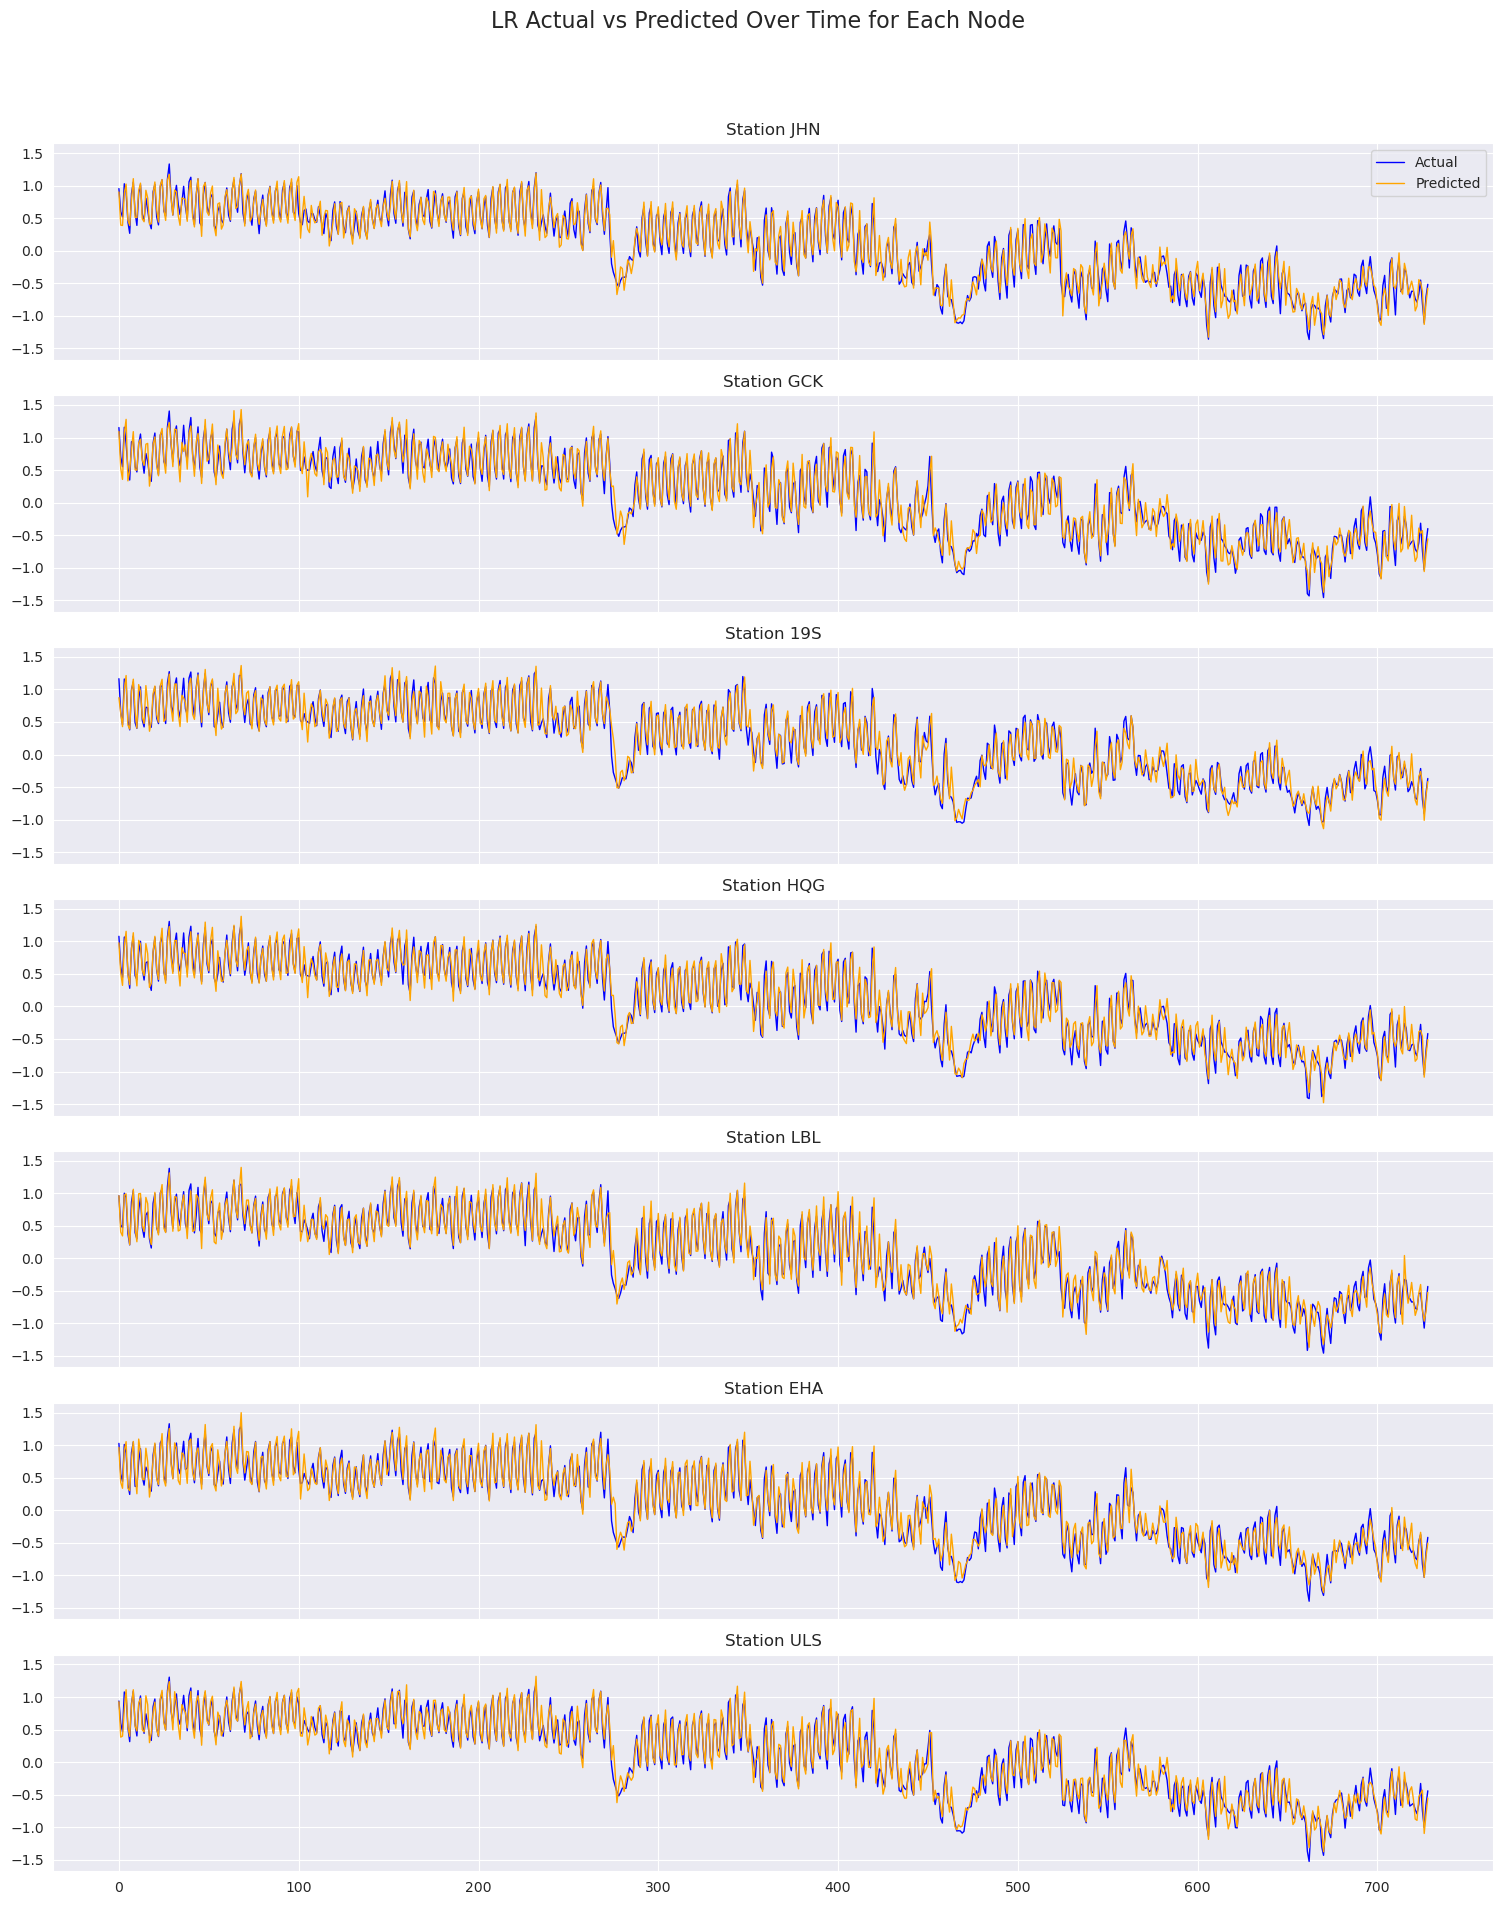

In [289]:
num_nodes = lagged_array[T-split_index:, :, :].shape[1]
num_time_steps = lagged_array[T-split_index:, :, :].shape[0]

cols = 1  # number of columns of facets
rows = num_nodes

fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=True, sharey=True)

for node in range(num_nodes):
    all_targets = lagged_array[T-split_index+1:, node, 0]
    all_preds = lr_model.predict(lagged_array[T-split_index:-1, node, :])
    ax = axes[node]
    ax.plot(all_targets, label='Actual', color='blue', linewidth=1)
    # ax.set_xlim(left=T-split_index*2, right=T+10)
    ax.plot(all_preds, label='Predicted', color='orange', linewidth=1)
    # ax.vlines(T-split_index, linestyles='dashed', ymin=-1.5, ymax=1.5, color='grey')
    ax.set_title(f'Station {stations_list[node]}')
    ax.grid(True)

# Only add legend to one plot
axes[0].legend(loc='upper right')

fig.suptitle("LR Actual vs Predicted Over Time for Each Node", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

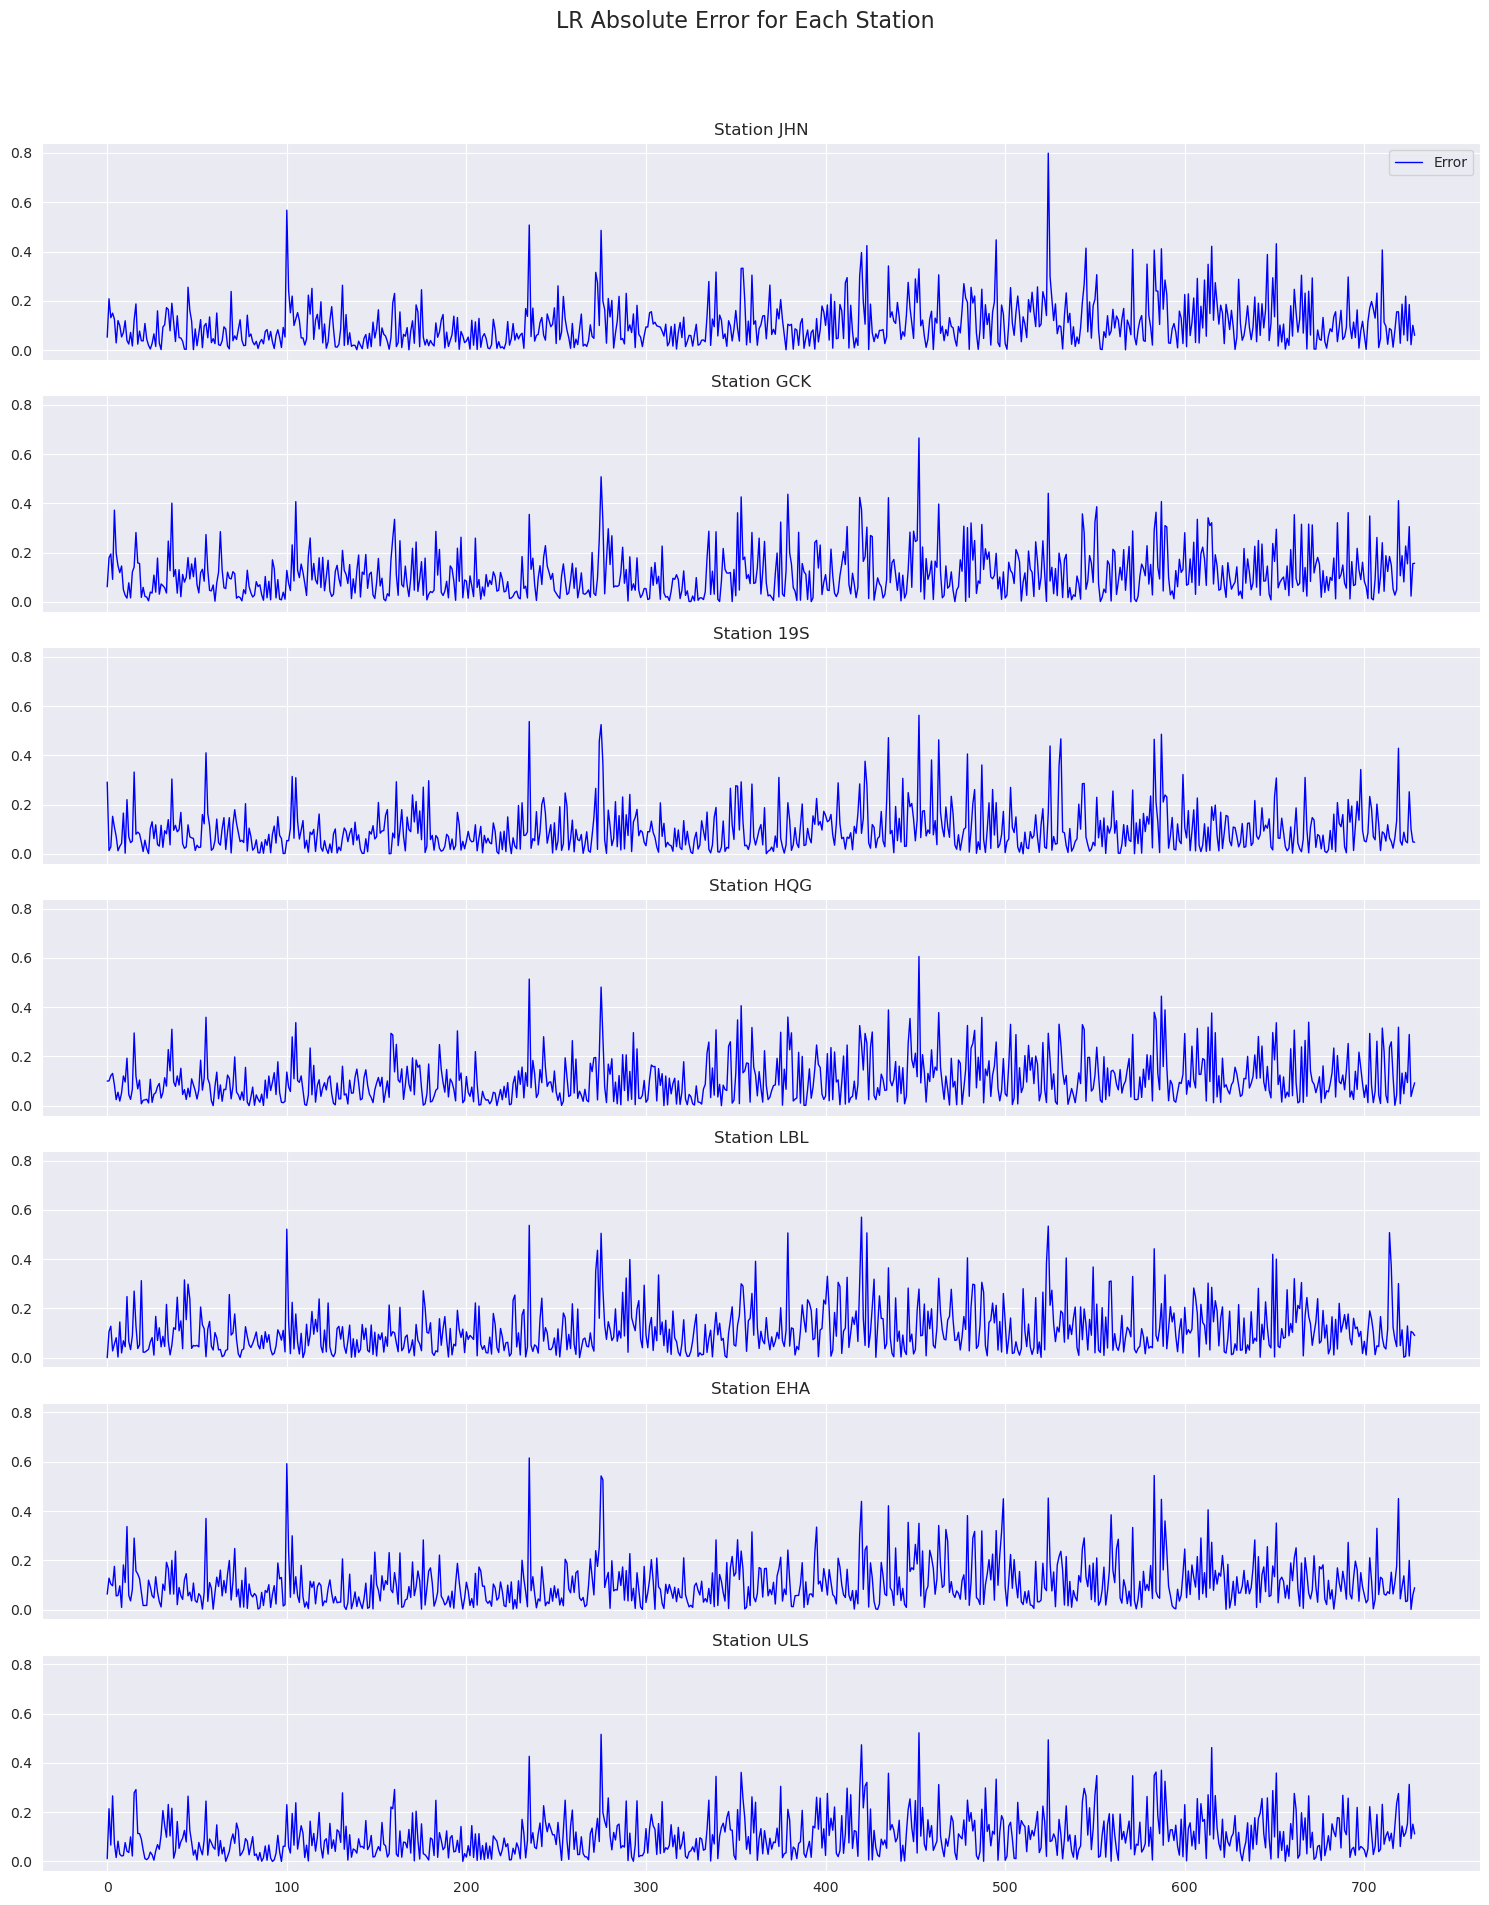

In [271]:
num_nodes = lagged_array[T-split_index:, :, :].shape[1]
num_time_steps = lagged_array[T-split_index:, :, :].shape[0]

cols = 1  # number of columns of facets
rows = num_nodes


fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=True, sharey=True)
for node in range(num_nodes):
    all_targets = lagged_array[T-split_index+1:, node, 0]
    all_preds = lr_model.predict(lagged_array[T-split_index:-1, node, :])
    lr_absolute_error = np.abs(np.subtract(all_targets, all_preds))

    ax = axes[node]
    ax.plot(lr_absolute_error, label='Error', color='blue', linewidth=1)
    ax.set_title(f'Station {stations_list[node]}')
    ax.grid(True)

# Only add legend to one plot
axes[0].legend(loc='upper right')

fig.suptitle("LR Absolute Error for Each Station", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

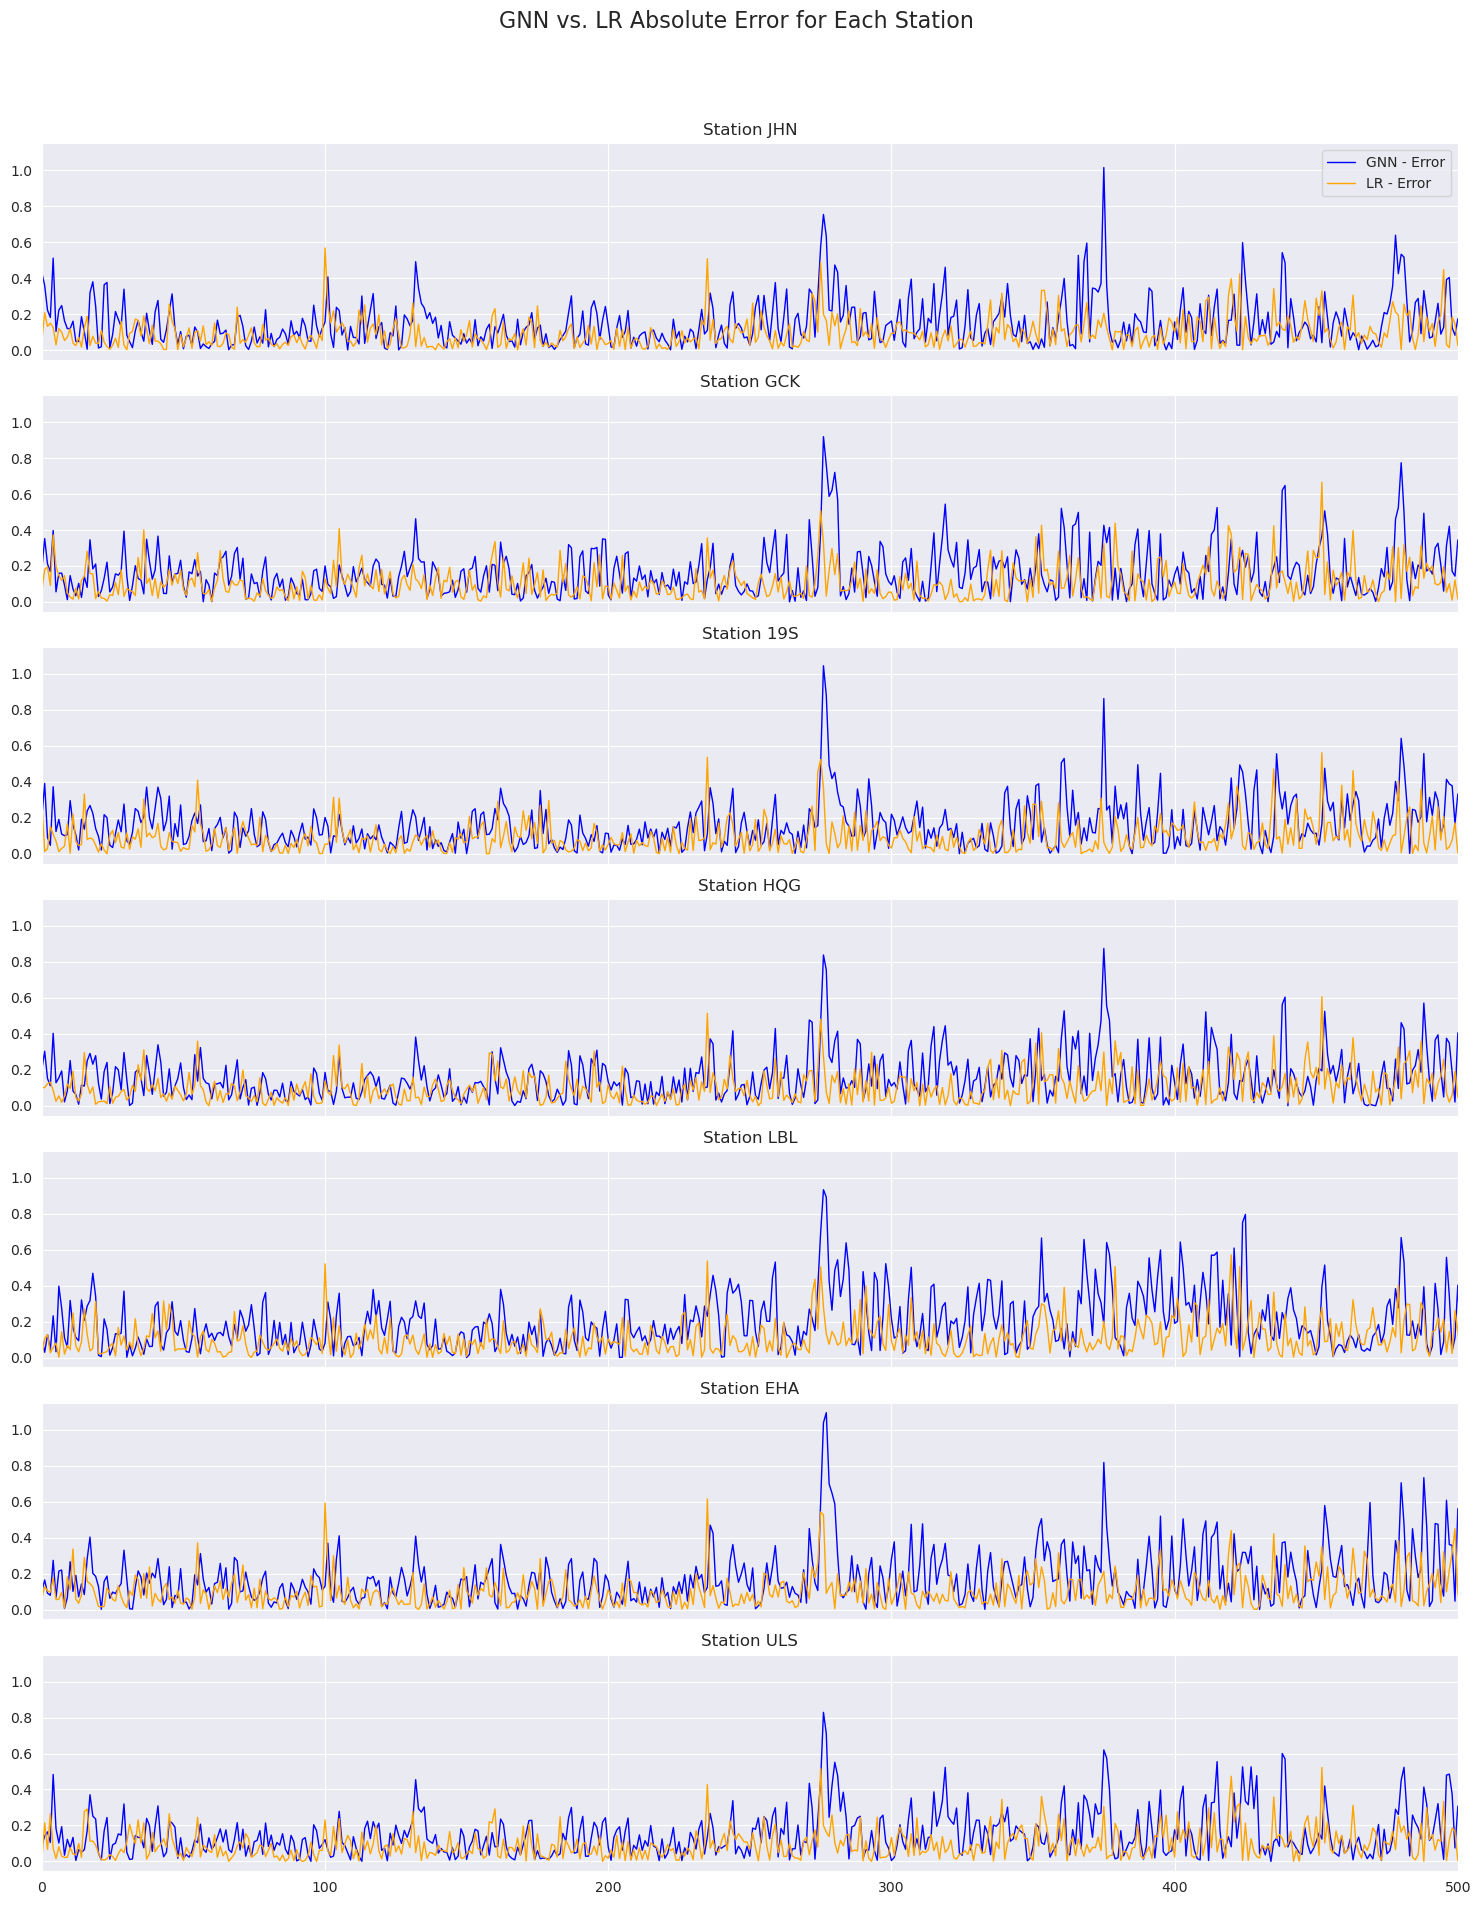

In [291]:
num_nodes = lagged_array[T-split_index:, :, :].shape[1]
num_time_steps = lagged_array[T-split_index:, :, :].shape[0]

cols = 1  # number of columns of facets
rows = num_nodes

all_preds = []
all_targets = []

gnn_model.eval()
with torch.no_grad():
    for snapshot in test_dataset:
        y_pred = gnn_model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze()
        y_true = snapshot.y.squeeze()
        all_preds.append(y_pred.cpu().numpy())
        all_targets.append(y_true.cpu().numpy())

# Convert to arrays: shape [num_snapshots, num_nodes]
all_preds = np.stack(all_preds)
all_targets = np.stack(all_targets)

gnn_absolute_error = np.abs(np.subtract(np.array(all_preds, dtype=float), np.array(all_targets, dtype=float)))

fig, axes = plt.subplots(rows, 1, figsize=(15, 20), sharex=True, sharey=True)
for node in range(num_nodes):
    all_targets = lagged_array[T-split_index+1:, node, 0]
    all_preds = lr_model.predict(lagged_array[T-split_index:-1, node, :])
    lr_absolute_error = np.abs(np.subtract(all_targets, all_preds))
    relative_error = np.abs(gnn_absolute_error[1:, node] - lr_absolute_error)

    # ax = axes[node, 0]
    # ax.plot(gnn_absolute_error[:, node], label='Error', color='blue', linewidth=1)
    # ax.set_title(f'GNN - Station {stations_list[node]}')
    #
    # ax = axes[node, 1]
    # ax.plot(lr_absolute_error, label='Error', color='orange', linewidth=1)
    # ax.set_title(f'LR - Station {stations_list[node]}')
    # ax.grid(True)

    ax = axes[node]
    ax.plot(gnn_absolute_error[:, node], label='GNN - Error', color='blue', linewidth=1)
    ax.plot(lr_absolute_error, label='LR - Error', color='orange', linewidth=1)
    # ax.plot(relative_error, label='Error', color='red', linewidth=1)
    ax.set_title(f'Station {stations_list[node]}')
    ax.set_xlim(left=0, right=500)

axes[0].legend(loc='upper right')

fig.suptitle("GNN vs. LR Absolute Error for Each Station", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

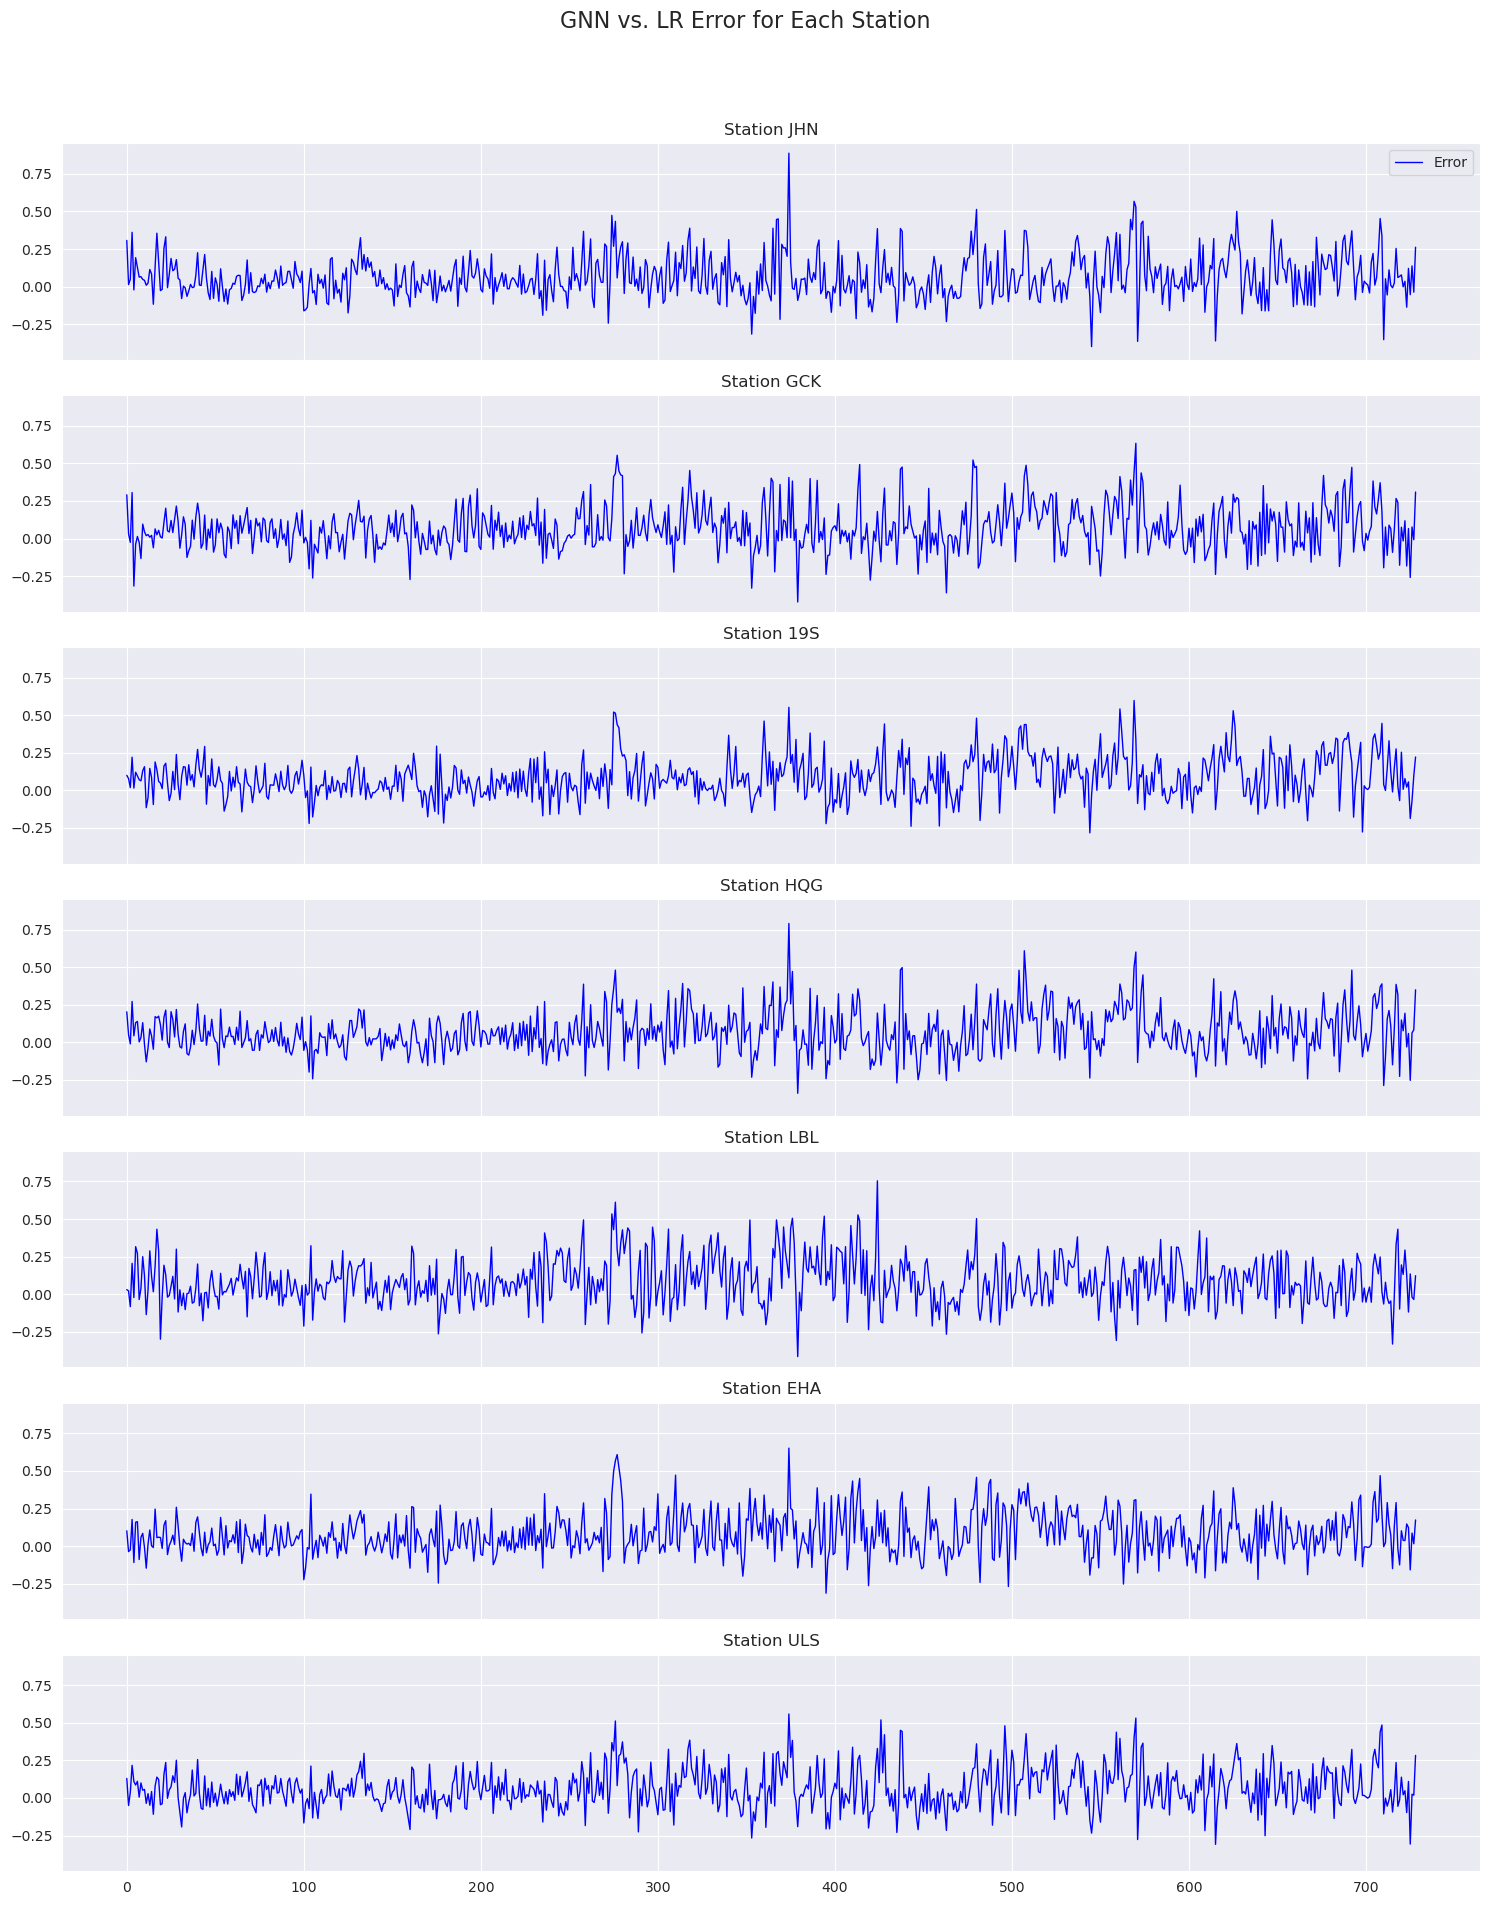

In [292]:
num_nodes = lagged_array[T-split_index:, :, :].shape[1]
num_time_steps = lagged_array[T-split_index:, :, :].shape[0]

cols = 1  # number of columns of facets
rows = num_nodes


fig, axes = plt.subplots(rows, cols, figsize=(15, 20), sharex=True, sharey=True)
for node in range(num_nodes):
    all_targets = lagged_array[T-split_index+1:, node, 0]
    all_preds = lr_model.predict(lagged_array[T-split_index:-1, node, :])
    lr_absolute_error = np.abs(np.subtract(all_targets, all_preds))

    relative_error = gnn_absolute_error[1:, node] - lr_absolute_error

    ax = axes[node]
    ax.plot(relative_error, label='Error', color='blue', linewidth=1)
    ax.set_title(f'Station {stations_list[node]}')
    ax.grid(True)

# Only add legend to one plot
axes[0].legend(loc='upper right')

fig.suptitle("GNN vs. LR Error for Each Station", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()